In [1]:
import numpy as np
import pandas as pd
import os
import torch
from torchvision import tv_tensors
import matplotlib.pyplot as plt
import pydicom
from PIL import Image
from tqdm import tqdm
import pickle
from copy import deepcopy

DATA_PATH = "D:/ML/RSNA2024"

In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Using {device} device")

Using cuda device


In [3]:
# CLASSES = ['L1/L2', 'L2/L3', 'L3/L4', 'L4/L5', 'L5/S1']
CLASSES = ['L5/S1', 'Other']
OTHER_CLASSES = ['L4/L5', 'L3/L4', 'L2/L3', 'L1/L2' ]
ALL_CLASSES=['L5/S1', 'L4/L5', 'L3/L4', 'L2/L3', 'L1/L2' ]
values = CLASSES
keys = np.arange(0,len(CLASSES))
IntToClass= dict(zip(keys, values))

classToInt = dict(zip(values, keys))

In [4]:
df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
df = df.fillna("Normal/Mild")


dfDescr = pd.read_csv(os.path.join(DATA_PATH, "train_series_descriptions.csv"))
uniqueSeriesDescr = np.array(['Sagittal T2/STIR', 'Sagittal T1', 'Axial T2'])
dfDescr.set_index("study_id", inplace=True)
uniqueStudIds = dfDescr.index.unique()

dfCoord = pd.read_csv(os.path.join(DATA_PATH, "train_label_coordinates.csv"))

In [5]:
dfDescr.head()

,series_id,series_description
study_id,,
4003253,702807833,Sagittal T2/STIR
4003253,1054713880,Sagittal T1
4003253,2448190387,Axial T2
4646740,3201256954,Axial T2
4646740,3486248476,Sagittal T1


In [6]:
from DicomDataset import *

### Position

The x, y, and z coordinates of the upper left hand corner (center of the first voxel transmitted) of the image, in mm

### Orientation

This means that the dicom world (or patient) coordinate system is LPS:

X is Right to Left (RL)
Y is Anterior to Posterior (AP)
Z is Inferior to Superior (IS)

The Image Orientation (Patient) dicom tag is (0020,0037), and is defined as 6 elements: "Ax, Ay, Az, Bx, By, Bz".

When described as a 3x3 rotation matrix R, it's equivalent to:


$$
\left(\begin{array}{cc} 
A_x & B_x & 0\\
A_y & B_y & 0\\
A_z & B_z & 0\\
\end{array}\right)
$$ 

### Pixel Spacing

Physical distance in the patient between the center of each pixel, specified by a numeric pair - adjacent row spacing (delimiter) adjacent column spacing in mm.

-----

## Data Extraction Process

1. For all patients create PatientData
1. Get all sagittal scans
1. Process every slice with the vertebrae detector
1. For every level L
    1. Get all patches from bounding boxes @ level L (extend the boxes to get the spinal canal and foramina!)
    1. Use a random slice where all levels can be seen to extract the axial slices @ level L. Also center crop them.

--> For every patient the data consists of separate data for every level

```json
{
    "L1/L2":
        {"sagittalPatches": [...], "axialSlices":[...]},
    "L2/L3":
        {"sagittalPatches": [...], "axialSlices":[...]},
    "L3/L4":
        ...
}

```

In [7]:
def createScanMapping(studyId):
    seriesIds = dfDescr.loc[studyId]["series_id"].to_numpy()
    seriesDescriptions = dfDescr.loc[studyId]["series_description"].to_numpy()
    scanMapping = []
    for seriesIndex,serId in enumerate(seriesIds):
        seriesDescr = seriesDescriptions[seriesIndex]
        if "Sagittal" in seriesDescr:
            orient = OrientationType.Sagittal
        elif "Axial" in seriesDescr or "Transversal" in seriesDescr:
            orient = OrientationType.Axial
        elif "Frontal" in seriesDescr:
            orient = OrientationType.Frontal
        else:
            orient = OrientationType.Unknown
        folder = os.path.join(DATA_PATH, f"train_images/{studyId}/{serId}")
        scanMapping.append((orient, folder))
    return scanMapping

In [8]:
vertebraeDetector = torch.load(os.path.join(DATA_PATH, "VertebraeDetectorBinary_epoch129_mAP0.5763.pth"))
vertebraeDetector.to(device)
vertebraeDetector.eval()

C:\Users\manue\AppData\Local\Temp\ipykernel_19468\3410995556.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vertebraeDetector = torch.load(os.path.join(DATA_PATH, "Vert

RetinaNet(
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      

In [9]:
import matplotlib.patches as patches


def plotImageWithAnnot(im, target, filename=None):
    fig, ax = plt.subplots()
    imsh = ax.imshow(im)
    fig.colorbar(imsh, ax=ax)

    for idx,b in enumerate(target["boxes"]):
        b = b.numpy()
        rect = patches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1], linewidth=1, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        plt.text(b[0], b[1]-4, IntToClass[target["labels"].numpy()[idx]], {"color":"red"})
    if filename:
        plt.title(filename)
        plt.tight_layout()
        plt.savefig(os.path.join(DATA_PATH, f"objDetExamples/{filename}.png"), dpi=120)
        plt.close()
    else:
        plt.show()

def plotImageWithBB(im, boundingBoxes, labels=None, filename=None):
    fig, ax = plt.subplots()
    imsh = ax.imshow(im)
    fig.colorbar(imsh, ax=ax)

    for idx,b in enumerate(boundingBoxes):
        b = b.numpy()
        rect = patches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1], linewidth=1, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        if not labels==None:
            plt.text(b[0], b[1]-4, IntToClass[labels.numpy()[idx]], {"color":"red"})
    if filename:
        plt.title(filename)
        plt.tight_layout()
        plt.savefig(os.path.join(DATA_PATH, f"objDetExamples/{filename}.png"), dpi=120)
        plt.close()
    else:
        plt.show()

In [10]:
def filterBoundingBoxes(targets, threshold=0.7):
    if type(targets)!=list:
        raise ValueError("targets has to be a list of dictionaries containing {'boxes':..., 'scores':..., 'labels':...}")
    filteredBB=[]
    for target in targets:
        scores = target["scores"].detach().cpu().numpy()
        boxes = target["boxes"].detach().cpu().numpy()
        labels = [IntToClass[el] for el in target["labels"].detach().cpu().numpy()]

        filtered={}
        newScores=[]

        for c in CLASSES:
            classIdxs = np.argwhere(np.array(labels)==c).flatten()
            if classIdxs.shape[0]==0:
                continue
            highestScore  = scores[classIdxs][0]
            if highestScore>threshold:
                filtered[c] = boxes[classIdxs[0]]
                newScores.append(highestScore)
        filteredBB.append({"filteredBB": filtered, "scores": newScores})
    return filteredBB



# testTar =[{'boxes': torch.tensor([[277.0559, 480.4082, 342.5710, 546.4760],
#           [246.1063, 421.0921, 322.0190, 465.9918],
#           [232.9959, 355.6693, 310.8026, 393.1955],
#           [235.5022, 282.2717, 309.8636, 314.1367],
#           [240.6923, 209.3363, 311.7209, 240.0908],
#           [240.8825, 210.6963, 311.3056, 239.0509],
#           [366.7859, 303.0891, 401.7643, 343.1634],
#           [244.8488, 142.8043, 313.3584, 171.8768],
#           [233.2152, 355.9161, 310.8337, 393.3716],
#           [277.0559, 480.4082, 342.5710, 546.4760],
#           [245.6599, 420.8578, 322.0050, 465.7909],
#           [362.5488, 364.8280, 410.1449, 413.4319],
#           [366.9376, 302.8406, 401.8413, 342.6856],
#           [366.8237, 302.9432, 401.6767, 343.5234]]),
#   'scores': torch.tensor([1.0000, 0.9999, 0.9998, 0.9985, 0.8368, 0.4317, 0.3369, 0.1112, 0.0953,
#           0.0714, 0.0698, 0.0658, 0.0620, 0.0581]),
#   'labels': torch.tensor([4, 3, 2, 1, 0, 1, 3, 0, 1, 3, 2, 4, 4, 0])}]

# filterBoundingBoxes(testTar)

In [11]:
def filterBoundingBoxesBinary(targets, threshold=0.7):
    if type(targets)!=list:
        raise ValueError("targets has to be a list of dictionaries containing {'boxes':..., 'scores':..., 'labels':...}")
    filteredBB=[]
    for target in targets:
        scores = target["scores"].detach().cpu().numpy()
        boxes = target["boxes"].detach().cpu().numpy()
        labels = [IntToClass[el] for el in target["labels"].detach().cpu().numpy()]

        output={}
        outputScores=[]

        if not "L5/S1" in labels:
            # No L5 found -> no assignment of all the other vertebrae possible
            filteredBB.append({})
            continue

        #Get L5/S1 with the highest score
        classIdxs = np.argwhere(np.array(labels)=="L5/S1").flatten()
        l5Scores  = np.array(scores)[classIdxs]
        l5Boxes = np.array(boxes)[classIdxs]
        highestL5ScoreIdx = np.argmax(l5Scores).flatten()
        l5Box = l5Boxes[highestL5ScoreIdx][0]
        l5Score = l5Scores[highestL5ScoreIdx]
        if l5Score<threshold:
            filteredBB.append({})
            continue
        output["L5/S1"] = {'filteredBB': l5Box, 'score': l5Score[0]}

        #Get all Other vertebrae with score > threshold
        classIdxs = np.argwhere((np.array(labels)=="Other") & (np.array(scores)>threshold)).flatten()
        otherBoxes = np.array(boxes)[classIdxs]
        otherScores = np.array(scores)[classIdxs]
        
        #Sort ascending by difference in y direction of the boxes to the L5 Box 
        yDistanceToL5 = [l5Box[3] - el[3] for el in otherBoxes]
        sortedIdxs = np.argsort(yDistanceToL5)
        otherBoxesSorted = otherBoxes[sortedIdxs]
        otherScoresSorted = otherScores[sortedIdxs]
        yDistanceToL5Sorted = np.array(yDistanceToL5)[sortedIdxs]


        levelIdx=0
        for i,otherBox in enumerate(otherBoxesSorted):
            if len(output.keys())==len(ALL_CLASSES):
                #Found all
                break
            if yDistanceToL5Sorted[i]<20:
                #If the other box is below or very close to L5, assume its detected as L5/S1 and another one simultaneously
                continue
            output[OTHER_CLASSES[levelIdx]]={'filteredBB': otherBox, 'score': otherScoresSorted[i]}
            levelIdx += 1
        filteredBB.append(output)
    return filteredBB





testTar =[{'boxes': torch.tensor([[277.0559, 480.4082, 342.5710, 546.4760],
          [246.1063, 421.0921, 322.0190, 465.9918],
          [232.9959, 355.6693, 310.8026, 393.1955],
          [235.5022, 282.2717, 309.8636, 314.1367],
          [240.6923, 209.3363, 311.7209, 240.0908],
          [240.8825, 210.6963, 311.3056, 239.0509],
          [366.7859, 303.0891, 401.7643, 343.1634],
          [244.8488, 142.8043, 313.3584, 171.8768],
          [233.2152, 355.9161, 310.8337, 393.3716],
          [277.0559, 480.4082, 342.5710, 546.4760],
          [245.6599, 420.8578, 322.0050, 465.7909],
          [362.5488, 364.8280, 410.1449, 413.4319],
          [366.9376, 302.8406, 401.8413, 342.6856],
          [366.8237, 302.9432, 401.6767, 343.5234]]),
  'scores': torch.tensor([1.0000, 0.9999, 0.9998, 0.9985, 0.8368, 0.4317, 0.3369, 0.1112, 0.0953,
          0.0714, 0.0698, 0.0658, 0.0620, 0.0581]),
  'labels': torch.tensor([0,0,1,1,1,1,1,1,1,1,1,1,1,1])}]

filterBoundingBoxesBinary(testTar)

[{'L5/S1': {'filteredBB': array([277.0559, 480.4082, 342.571 , 546.476 ], dtype=float32),
   'score': 1.0},
  'L4/L5': {'filteredBB': array([232.9959, 355.6693, 310.8026, 393.1955], dtype=float32),
   'score': 0.9998},
  'L3/L4': {'filteredBB': array([235.5022, 282.2717, 309.8636, 314.1367], dtype=float32),
   'score': 0.9985},
  'L2/L3': {'filteredBB': array([240.6923, 209.3363, 311.7209, 240.0908], dtype=float32),
   'score': 0.8368}}]

In [12]:
def extractPatch(im:np.array, bb, extensionFactor=0.0):
    # bb format: x1,y1,x2,y2
    if len(im.shape)!=2:
        raise ValueError(f"im has to be of shape (width, height) instead of {im.shape}")
    bbExt = [*bb]
    if extensionFactor>0:
        bbExt[0], bbExt[1] = np.clip(bbExt[0]*(1-extensionFactor), 0, im.shape[1]), np.clip(bbExt[1]*(1-extensionFactor), 0, im.shape[1])
        bbExt[2], bbExt[3] = np.clip(bbExt[2]*(1+extensionFactor), 0, im.shape[0]), np.clip(bbExt[3]*(1+extensionFactor), 0, im.shape[0])
    bbExt = [int(np.round(el)) for el in bbExt]
    # np array has height x width !
    return im[bbExt[1]:bbExt[3], bbExt[0]:bbExt[2]]

def extendBoundingBox(im:np.array, bb, extensionFactor=0.0):
    # bb format: x1,y1,x2,y2
    if len(im.shape)!=2:
        raise ValueError(f"im has to be of shape (width, height) instead of {im.shape}")
    bbExt = [*bb]
    if extensionFactor>0:
        bbExt[0], bbExt[1] = np.clip(bbExt[0]*(1-extensionFactor), 0, im.shape[1]), np.clip(bbExt[1]*(1-extensionFactor), 0, im.shape[1])
        bbExt[2], bbExt[3] = np.clip(bbExt[2]*(1+extensionFactor), 0, im.shape[0]), np.clip(bbExt[3]*(1+extensionFactor), 0, im.shape[0])
    bbExt = [int(np.round(el)) for el in bbExt]
    return bbExt

In [13]:
import plotly.graph_objs as go
import plotly.io as pio

def Visualize3DPointsAndSlices(points_list, colors=None, sliceList:list[Slice]=None):
    """
    Visualizes multiple lists of 3D points and optionally adds 3D planes representing slices, each with a different color,
    in an interactive 3D plot.

    Parameters:
        points_list (list of lists): A list of lists, where each sublist contains arrays of 3D points (x, y, z).
        colors (list of str): A list of colors for each set of points. Defaults to None, which uses a default color cycle.
        sliceList (list of dicts): A list of slices, where each slice is a dictionary with properties:
                                   'pixelSpacing' (2D vector), 'data' (2D numpy array), 
                                   'position' (3D vector), and 'orientation' (6D vector).
    """
    data = []
    
    # Generate a color palette if no colors are provided
    if colors is None:
        colors = ['blue', 'red', 'green', 'purple', 'orange', 'yellow', 'cyan', 'magenta']
    colorIdx=0
    
    # Loop through each list of points and corresponding color
    for i, points in enumerate(points_list):
        x_coords = [point[0] for point in points]
        y_coords = [point[1] for point in points]
        z_coords = [point[2] for point in points]
        
        scatter = go.Scatter3d(
            x=x_coords, 
            y=y_coords, 
            z=z_coords,
            mode='markers',
            marker=dict(
                size=5,
                color=colors[colorIdx % len(colors)],  # Cycle through the colors if more point sets than colors
                opacity=0.8
            ),
            name=f'Set {i+1}'  # Optional: Name each set
        )
        colorIdx += 1
        
        data.append(scatter)
    
    # Loop through each slice in the sliceList and add the plane
    if sliceList is not None:
        for idx, slice in enumerate(sliceList):
            # Extract the slice properties
            pixel_spacing = slice.pixelSpacing  # 2D vector
            position = np.array(slice.position)  # 3D vector
            orientation = np.array(slice.orientation)  # 6D vector (first 3 for row, next 3 for column)
            
            # Split the orientation into row and column vectors
            row_vector = orientation[:3]
            column_vector = orientation[3:]
            
            slice_height, slice_width = slice.data.shape  # Dimensions of the 2D slice (in pixels)
            
            # Calculate the four corners of the slice plane in 3D space
            top_left = position
            top_right = top_left + row_vector * slice_width * pixel_spacing[0]
            bottom_left = top_left + column_vector * slice_height * pixel_spacing[1]
            bottom_right = bottom_left + row_vector * slice_width * pixel_spacing[0]
            
            # Coordinates of the four corners
            x_coords = [top_left[0], top_right[0], bottom_right[0], bottom_left[0]]
            y_coords = [top_left[1], top_right[1], bottom_right[1], bottom_left[1]]
            z_coords = [top_left[2], top_right[2], bottom_right[2], bottom_left[2]]
            
            # Add the slice plane as a mesh to the plot
            plane = go.Mesh3d(
                x=x_coords,
                y=y_coords,
                z=z_coords,
                color=colors[colorIdx % len(colors)],  # Cycle through the colors if more slices than colors
                opacity=0.5,
                i=[0, 0, 0],
                j=[1, 2, 3],
                k=[2, 3, 1],
                name=f'Slice {idx+1}'  # Name each slice
            )
            
            data.append(plane)
    
    # Creating the layout for the plot
    layout = go.Layout(
        scene=dict(
            xaxis=dict(title='X Axis'),
            yaxis=dict(title='Y Axis'),
            zaxis=dict(title='Z Axis')
        ),
        margin=dict(l=0, r=0, b=0, t=0),  # Set margins
        legend=dict(x=0, y=1)  # Position the legend
    )
    
    fig = go.Figure(data=data, layout=layout)
    
    pio.show(fig)
    # return fig

Visualize3DPointsAndSlices(np.array([[[1,2,3]]]), sliceList=[Slice(np.random.random((50,50)), "123", "123", np.array([2,2,2]), np.array([0,1,0,0,0,1]), [0.5,0.5], [0.5,0.5])])

In [14]:
if os.path.exists(os.path.join(DATA_PATH,"./rawData.pkl")):
    with open(os.path.join(DATA_PATH,"./rawData.pkl"), "rb") as f:
        allData = pickle.load(f)
else:
    with torch.no_grad():
        allData = {}
        allPoints = {}
        for studyId in tqdm(uniqueStudIds):
            scanMapping = createScanMapping(studyId)
            patData = PatientData(scanMapping)
            sagScans = patData.getSagittalScans()
            allPoints[studyId] = {"axialPoints":[el.position for el in patData.getAxialScans()[0].slices], "sagittalPoints": [el.position for el in sagScans[0].slices]}
            sagittalPatches=dict(zip(ALL_CLASSES, [ [] for _ in range(len(ALL_CLASSES)) ]))
            axScans = patData.getAxialScans()
            axSlices=dict(zip(ALL_CLASSES, [ [] for _ in range(len(ALL_CLASSES)) ]))
            axSlicesExtracted = False
            
            for s in sagScans:
                for slice in s.slices:
                    # im = torch.tensor(slice.data.astype(np.float32)/255.0).to(device)
                    im = tv_tensors.Image(slice.data.astype(np.float32)/255.0).to(device)
                    targets = vertebraeDetector([im])
                    filteredBoundingBoxesList = filterBoundingBoxesBinary(targets, 0.7)
                    filteredBoundingBoxes = filteredBoundingBoxesList[0]
                    if len(filteredBoundingBoxes.keys())==0:
                        #No vertebrae visible
                        continue

                    # Get sagittal patches
                    for cl in filteredBoundingBoxes.keys():
                        bb = filteredBoundingBoxes[cl]["filteredBB"]
                        patch = extractPatch(im.detach().cpu().numpy()[0,:,:], bb, 0.1)
                        sagittalPatches[cl].append((patch*255).astype(np.uint8))

                    # Get axial slices
                    # allLevelsVisible = np.all([el in list(filteredBoundingBoxes.keys()) for el in CLASSES])
                    allLevelsVisible = np.all([el in list(filteredBoundingBoxes.keys()) for el in OTHER_CLASSES])
                    axSlicesTemp = {}
                    if allLevelsVisible and not axSlicesExtracted:
                        #If there are bounding boxes of all 5 levels
                        #Get the slices that are in the range of that bounding box
                        for cl in filteredBoundingBoxes.keys():
                            bb = filteredBoundingBoxes[cl]["filteredBB"]
                            bb = extendBoundingBox(im.detach().cpu().numpy()[0,:,:], bb, 0.1)
                            startPos = slice.getWorldPosition(0,bb[3])
                            endPos = slice.getWorldPosition(0,bb[1])
                            axSlicesInRange = patData.getSlicesInRangeDirection(axScans[0], startPos, endPos, Direction.Z)
                            if len(axSlicesInRange)<1:
                                #Didnt find enough slices -> continue
                                axSlicesTemp[cl] = []
                                continue
                            axSlicesTemp[cl] = axSlicesInRange

                        # allLevelsDetected = np.all([el in list(axSlicesTemp.keys()) for el in ALL_CLASSES])
                        # if allLevelsDetected:
                        axSlices = deepcopy(axSlicesTemp)
                        axSlicesExtracted=True
                        foundLevels = list(axSlicesTemp.keys())
            if not len(foundLevels) == len(ALL_CLASSES) :
                print(f"Not all axial slices found for {studyId}: {foundLevels}")
            allData[studyId] = {"axSlices": axSlices, "sagittalPatches": sagittalPatches}
                
        with open(os.path.join(DATA_PATH,"./rawData.pkl"), "wb") as f:
            pickle.dump(allData, f)


  0%|          | 4/1975 [00:05<43:59,  1.34s/it]

Not all axial slices found for 8785691: ['L5/S1', 'L4/L5', 'L3/L4', 'L2/L3']


  0%|          | 7/1975 [00:13<1:12:01,  2.20s/it]

Not all axial slices found for 11943292: ['L4/L5', 'L3/L4', 'L2/L3', 'L1/L2']


  1%|          | 16/1975 [00:35<1:32:06,  2.82s/it]

...

 99%|█████████▉| 1964/1975 [1:21:07<00:30,  2.76s/it]

Not all axial slices found for 4269243363: ['L5/S1', 'L4/L5', 'L3/L4', 'L2/L3']


100%|█████████▉| 1970/1975 [1:21:30<00:19,  3.85s/it]

Not all axial slices found for 4279958262: ['L5/S1', 'L4/L5', 'L3/L4', 'L2/L3']


100%|██████████| 1975/1975 [1:21:47<00:00,  2.48s/it]


In [15]:
# Plot all BBs
# plotImageWithBB(im.detach().cpu().numpy()[0,:,:], [torch.tensor(filteredBoundingBoxes[el]["filteredBB"]) for el in ALL_CLASSES], torch.tensor([0,1,1,1,1]))

# Plot current BB
# plotImageWithBB(im.detach().cpu()[0,:,:], torch.tensor([bb]))

#Visualize 3D world
# Visualize3DPointsAndSlices([[startPos],[endPos], [s.getWorldPosition(s.data.shape[0]//2, s.data.shape[1]//2) for s in patData.getAxialScans()[0].slices]], sliceList=patData.getAxialScans()[0].slices)

In [39]:
testStudyId = list(allData.keys())[112]
testData = allData[list(allData.keys())[112]]
print(testStudyId)

233373921


In [40]:
Visualize3DPointsAndSlices([allPoints[testStudyId]["axialPoints"], allPoints[testStudyId]["sagittalPoints"]])

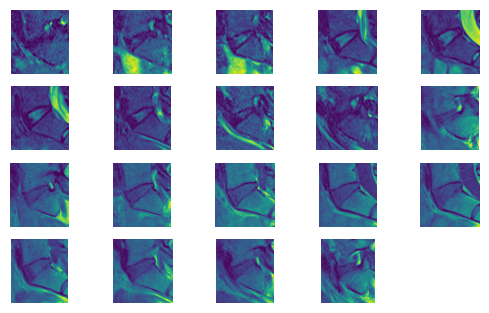

In [41]:
numIm = int(np.ceil(np.sqrt(len(testData["sagittalPatches"]["L5/S1"]))))
for i,im in enumerate(testData["sagittalPatches"]["L5/S1"]):
    plt.subplot(numIm, numIm, i+1)
    plt.imshow(im)
    plt.axis("off")

In [38]:
testData["axSlices"]

{'L5/S1': [<DicomDataset.Slice at 0x1ab792ae4e0>,
 'L4/L5': [<DicomDataset.Slice at 0x1ab96c7ba70>,
 'L3/L4': [<DicomDataset.Slice at 0x1ab96c7bbc0>,
 'L2/L3': [<DicomDataset.Slice at 0x1ab94b2a9f0>,
 'L1/L2': [<DicomDataset.Slice at 0x1ab94b28ce0>,
  <DicomDataset.Slice at 0x1ab94b2a1b0>]}

L5/S1
L4/L5
L3/L4
L2/L3
L1/L2


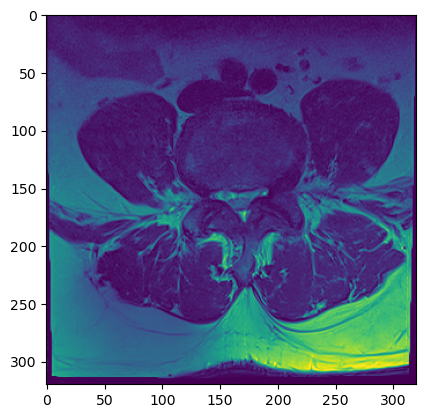

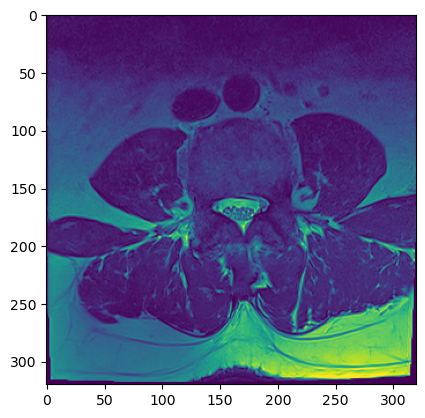

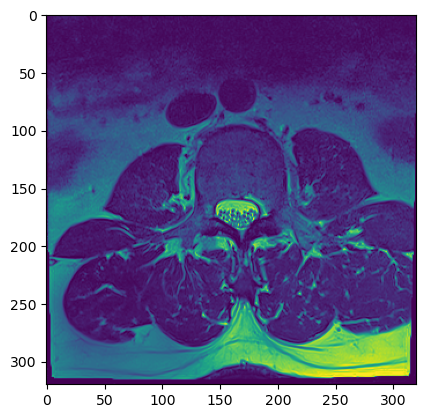

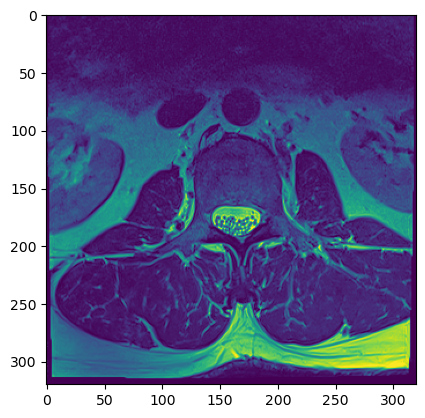

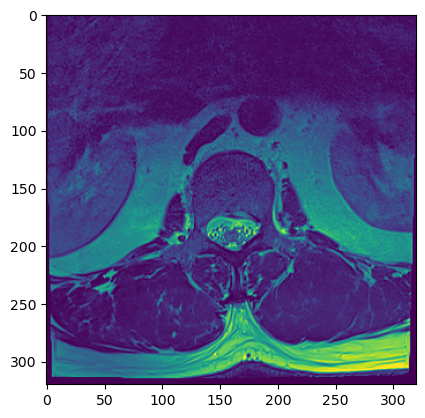

In [33]:
for c in ALL_CLASSES:
    print(c)
    testData["axSlices"][c][0].plot()

In [34]:
from scipy.ndimage import zoom
from PIL import Image

def plotMriVolume(slices):
    im=Image.fromarray(slices[0].data)
    xCount = int(slices[0].data.shape[0]*0.1)
    yCount = int(slices[0].data.shape[1]*0.1)
    im = im.resize(( xCount, yCount ))
    # Calculate the extent of the volume in millimeters
    zCount = len(slices)

    X, Y, Z = np.mgrid[0:xCount, 0:yCount, 0:zCount]

    # Initialize the volume with zeros
    volume = np.zeros((xCount,yCount,zCount), dtype=np.float32)
    
    for i, s in enumerate(slices):
        im=Image.fromarray(s.data)
        im = im.resize(( xCount, yCount ))
        # Insert the slice into the volume
        volume[:,:,i] = np.array(im)
    
    # Normalize the volume data
    # volume = (volume - np.min(volume)) / (np.max(volume) - np.min(volume))
    
    # Create a 3D volume plot
    fig = go.Figure(data=go.Volume(
        x=X.flatten(),
        y=Y.flatten(),
        z=Z.flatten(),
        value=volume.flatten(),
        opacity=0.5,
        surface_count=25,
        colorscale='Gray'
    ))

    print(volume.flatten().shape)

    # Set the correct axis labels and ranges
    fig.update_layout(scene=dict(
        xaxis=dict(range=[0, xCount], title='X (mm)'),
        yaxis=dict(range=[0, yCount], title='Y (mm)'),
        zaxis=dict(range=[0, zCount], title='Z (mm)')
    ))
    
    pio.show(fig)


# plotMriVolume(patData.getAxialScans()[0].slices)